# Multi-Agent Path Finding (MAPF) Demo

This notebook demonstrates how to use the MAPF solver from `extern/mapf/` to find optimal paths for multiple agents and visualize the result as an animated GIF.

The MAPF solver uses Improved Conflict-Based Search (ICBS) to find collision-free paths for multiple agents moving on a grid.

## Setup

First, we'll add the MAPF code to our Python path and import the necessary modules.

In [5]:
import sys
import os

# Add the MAPF code directory to the Python path
mapf_path = os.path.abspath('../extern/mapf/code')
if mapf_path not in sys.path:
    sys.path.insert(0, mapf_path)

# Import MAPF modules
from cbs_basic import CBSSolver
from icbs_complete import ICBS_Solver
from visualize import Animation
from single_agent_planner import get_sum_of_cost

print("MAPF modules loaded successfully!")

MAPF modules loaded successfully!


## Define the Map and Agents

Let's create a simple example with a grid map and multiple agents.

- `True` = obstacle
- `False` = free space
- `starts` = list of (row, col) starting positions
- `goals` = list of (row, col) goal positions

In [6]:
# Define a simple 8x8 map with some obstacles
my_map = [
    [False, False, True,  False, False, False, False, False],
    [False, False, False, True,  False, False, False, False],
    [False, False, True,  False, False, False, False, False],
    [False, False, False, False, False, False, False, False],
    [False, False, False, False, False, False, False, True],
    [False, False, False, False, False, True,  False, False],
    [False, False, False, False, False, False, True,  False],
    [False, False, False, False, False, False, False, False],
]

# Define start and goal positions for 3 agents
starts = [
    (1, 1),  # Agent 0
    (7, 6),  # Agent 1
    (4, 3),  # Agent 2
]

goals = [
    (3, 0),  # Agent 0
    (0, 0),  # Agent 1
    (1, 1),  # Agent 2
]

print(f"Map size: {len(my_map)}x{len(my_map[0])}")
print(f"Number of agents: {len(starts)}")
print(f"Start positions: {starts}")
print(f"Goal positions: {goals}")

Map size: 8x8
Number of agents: 3
Start positions: [(1, 1), (7, 6), (4, 3)]
Goal positions: [(3, 0), (0, 0), (1, 1)]


## Solve the MAPF Problem

Now we'll use the ICBS solver to find optimal collision-free paths for all agents.

You can choose between:
- **Standard splitting**: Traditional CBS constraint generation
- **Disjoint splitting**: A newer method that can be more efficient

In [7]:
# Create the solver (ICBS = Improved CBS with all improvements)
solver = ICBS_Solver(my_map, starts, goals)

# Find solution using disjoint splitting (set to False for standard splitting)
use_disjoint = True
print(f"Solving with {'disjoint' if use_disjoint else 'standard'} splitting...")

solution = solver.find_solution(use_disjoint)

if solution is not None:
    paths, nodes_generated, nodes_expanded = solution
    
    if paths is not None:
        cost = get_sum_of_cost(paths)
        print(f"\n✓ Solution found!")
        print(f"  Sum of costs: {cost}")
        print(f"  Nodes generated: {nodes_generated}")
        print(f"  Nodes expanded: {nodes_expanded}")
        print(f"\nPaths:")
        for i, path in enumerate(paths):
            print(f"  Agent {i}: {path}")
    else:
        print("✗ No solution found")
else:
    print("✗ Solver failed to find a solution")

Solving with disjoint splitting...
> build constraint table
{}
[(1, 1), (1, 0), (2, 0), (3, 0)]
> build constraint table
{}
[(7, 6), (7, 5), (6, 5), (6, 4), (5, 4), (4, 4), (3, 4), (3, 3), (3, 2), (3, 1), (2, 1), (1, 1), (0, 1), (0, 0)]
> build constraint table
{}
[(4, 3), (3, 3), (3, 2), (3, 1), (2, 1), (1, 1)]
> Generate node 0 with cost 21


> Expand node 0 with cost 21
Node expanded. Collisions:  [{'a1': 1, 'ma1': {1}, 'a2': 2, 'ma2': {2}, 'loc': [(1, 1)], 'timestep': 11}]
[(1, 1), (1, 0), (2, 0), (3, 0)]
[(7, 6), (7, 5), (6, 5), (6, 4), (5, 4), (4, 4), (3, 4), (3, 3), (3, 2), (3, 1), (2, 1), (1, 1), (0, 1), (0, 0)]
[(4, 3), (3, 3), (3, 2), (3, 1), (2, 1), (1, 1)]

> Find Collision Type
{'a1': 1, 'ma1': {1}, 'a2': 2, 'ma2': {2}, 'loc': [(1, 1)], 'timestep': 11}
> build constraint table
{11: [{'agent': 1, 'meta_agent': {1}, 'loc': [(1, 1)], 'timestep': 11, 'positive': False}]}
[(7, 6), (7, 5), (6, 5), (6, 4), (5, 4), (4, 4), (3, 4), (3, 3), (3, 2), (3, 1), (2, 1), (2, 0), (1, 0), (0

## Visualize and Save as GIF

Finally, we'll create an animation and save it as a GIF file.

The animation shows:
- **Gray squares**: Obstacles
- **Colored circles**: Agents (with numbers)
- **Transparent colored squares**: Goal positions
- Agents will turn **red** if they collide

MovieWriter ffmpeg unavailable; using Pillow instead.


Saving animation to data/mapf_solution.gif...
✓ Animation saved!
✓ Animation saved!


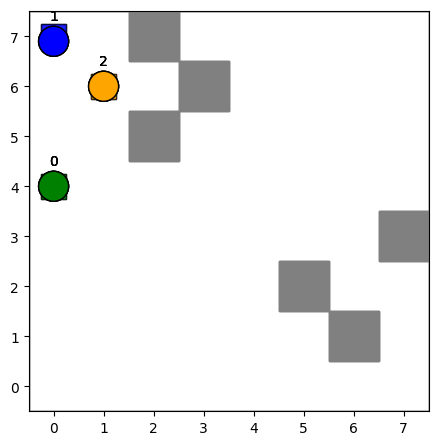

In [8]:
# Create animation
animation = Animation(my_map, starts, goals, paths)

# Save as GIF
output_file = 'data/mapf_solution.gif'
speed = 1.0  # Animation speed (higher = faster)

print(f"Saving animation to {output_file}...")
animation.save(output_file, speed)
print(f"✓ Animation saved!")

## Display the Animation

If you're running this in a notebook with display capabilities, you can also show the animation directly:

In [ ]:
# Display the animation in the notebook (optional)
# Note: This will open a matplotlib window
# animation.show()

## Load and Solve from a File

You can also load pre-defined problem instances from files. Here's an example using one of the test instances:

In [ ]:
from pathlib import Path

def import_mapf_instance(filename):
    """Load a MAPF instance from a text file."""
    f = Path(filename)
    if not f.is_file():
        raise FileNotFoundError(f"{filename} does not exist.")
    
    with open(filename, 'r') as file:
        # First line: #rows #columns
        line = file.readline()
        rows, columns = [int(x) for x in line.split(' ')]
        
        # Parse the map
        my_map = []
        for r in range(rows):
            line = file.readline()
            my_map.append([])
            for cell in line:
                if cell == '@':
                    my_map[-1].append(True)   # Obstacle
                elif cell == '.':
                    my_map[-1].append(False)  # Free space
        
        # Number of agents
        line = file.readline()
        num_agents = int(line)
        
        # Start/goal positions
        starts = []
        goals = []
        for a in range(num_agents):
            line = file.readline()
            sx, sy, gx, gy = [int(x) for x in line.split(' ')]
            starts.append((sx, sy))
            goals.append((gx, gy))
    
    return my_map, starts, goals

# Load an example instance
instance_file = '../extern/mapf/code/instances/test_1.txt'
my_map_file, starts_file, goals_file = import_mapf_instance(instance_file)

print(f"Loaded instance from {instance_file}")
print(f"Map size: {len(my_map_file)}x{len(my_map_file[0])}")
print(f"Number of agents: {len(starts_file)}")

# Solve it
solver_file = ICBS_Solver(my_map_file, starts_file, goals_file)
solution_file = solver_file.find_solution(True)

if solution_file and solution_file[0]:
    paths_file = solution_file[0]
    print(f"✓ Solution found with cost: {get_sum_of_cost(paths_file)}")
    
    # Create and save animation
    animation_file = Animation(my_map_file, starts_file, goals_file, paths_file)
    animation_file.save('data/mapf_solution_from_file.gif', 1.0)
    print("✓ Animation saved to data/mapf_solution_from_file.gif")
else:
    print("✗ No solution found")

## Summary

This notebook demonstrated how to:

1. Set up and import the MAPF solver from `extern/mapf/`
2. Define a grid map with obstacles and agent start/goal positions
3. Solve the multi-agent pathfinding problem using ICBS
4. Generate and save an animated GIF showing the solution
5. Load and solve problem instances from files

The generated GIF files can be found in the `data/` directory.